<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
C:\Users\luiz.melo\AppData\Local\Temp\ipykernel_18388\2615786396.py:30: SyntaxWarning: invalid escape sequence '\c'
  axs[i, 0].set_title(f'Tempo: {labels[i]} ($T_s = {int(k)} \cdot T_b$)', fontweight='bold')


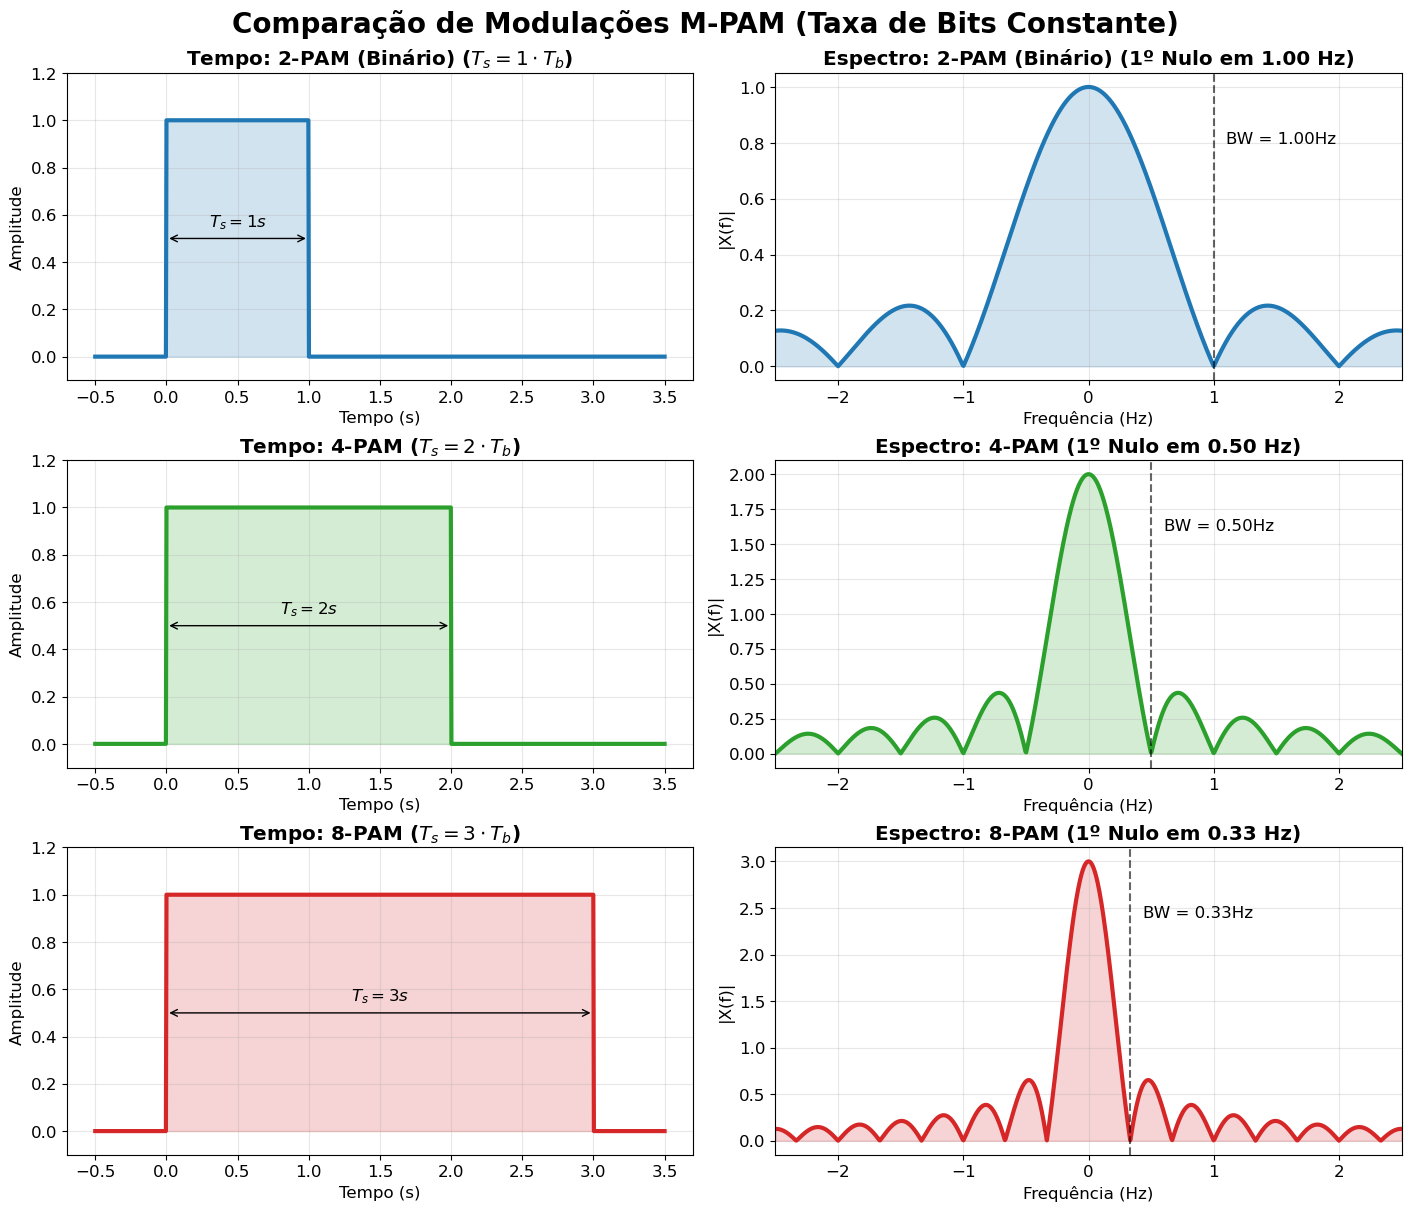


As figuras foram salvas como 'comparacao_mpam_slides.png' e 'comparacao_mpam_slides.pdf' no diretório atual.
Você pode inseri-las diretamente nos seus slides.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações de estilo para slides
plt.rcParams.update({'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3})

# Parâmetros
Rb = 1.0  # Taxa de bits (bits/s)
orders = [2, 4, 8]
labels = ['2-PAM (Binário)', '4-PAM', '8-PAM']
colors = ['#1f77b4', '#2ca02c', '#d62728']

# Eixos de tempo e frequência
t = np.linspace(-0.5, 3.5, 1000)
f = np.linspace(-2.5, 2.5, 1000)

fig, axs = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
fig.suptitle('Comparação de Modulações M-PAM (Taxa de Bits Constante)', fontsize=20, fontweight='bold')

for i, M in enumerate(orders):
    k = np.log2(M)
    Ts = k / Rb
    
    # --- Coluna 1: Domínio do Tempo ---
    # Gerando o pulso quadrado
    pulse = np.where((t >= 0) & (t <= Ts), 1.0, 0.0)
    
    axs[i, 0].plot(t, pulse, color=colors[i], lw=3)
    axs[i, 0].fill_between(t, pulse, color=colors[i], alpha=0.2)
    axs[i, 0].set_title(f'Tempo: {labels[i]} ($T_s = {int(k)} \cdot T_b$)', fontweight='bold')
    axs[i, 0].set_ylabel('Amplitude')
    axs[i, 0].set_ylim(-0.1, 1.2)
    axs[i, 0].set_xlabel('Tempo (s)')
    
    # Marcador da duração do pulso
    axs[i, 0].annotate('', xy=(Ts, 0.5), xytext=(0, 0.5),
                       arrowprops=dict(arrowstyle='<->', color='black'))
    axs[i, 0].text(Ts/2, 0.55, f'$T_s = {k:.0f}s$', ha='center')

    # --- Coluna 2: Domínio da Frequência ---
    # Espectro: X(f) = Ts * sinc(f * Ts)
    spectrum = Ts * np.sinc(f * Ts)
    magnitude = np.abs(spectrum)
    
    axs[i, 1].plot(f, magnitude, color=colors[i], lw=3)
    axs[i, 1].fill_between(f, magnitude, color=colors[i], alpha=0.2)
    axs[i, 1].set_title(f'Espectro: {labels[i]} (1º Nulo em {1/Ts:.2f} Hz)', fontweight='bold')
    axs[i, 1].set_ylabel('|X(f)|')
    axs[i, 1].set_xlabel('Frequência (Hz)')
    axs[i, 1].set_xlim(-2.5, 2.5)
    
    # Marcar o primeiro nulo (Largura de Banda)
    null_freq = 1/Ts
    axs[i, 1].axvline(null_freq, color='black', linestyle='--', alpha=0.6)
    axs[i, 1].text(null_freq + 0.1, max(magnitude)*0.8, f'BW = {null_freq:.2f}Hz', rotation=0)

# --- Salvando a figura ---
# Salvar em PNG para slides (boa qualidade, bom tamanho)
fig.savefig('comparacao_mpam_slides.png', dpi=300, bbox_inches='tight')
# Salvar em PDF para documentos ou caso precise de qualidade vetorial máxima
fig.savefig('comparacao_mpam_slides.pdf', bbox_inches='tight')

plt.show()

print("\nAs figuras foram salvas como 'comparacao_mpam_slides.png' e 'comparacao_mpam_slides.pdf' no diretório atual.")
print("Você pode inseri-las diretamente nos seus slides.")